# Wave Data Preparation: Copernicus/EMODnet In-Situ Sea-State Data for WEC Power Estimation

## Purpose

This notebook retrieves, inspects, cleans, and prepares measured in-situ wave observations from the Leixões coastal buoy.

The prepared dataset provides the sea-state time series needed for the next analyses, including simplified WEC power estimation from wave-height and period variables, short-term forecasting, prediction intervals, and storage-aware smoothing metrics.

## Data source

The selected source is the Leixões coastal buoy, available through Copernicus Marine / EMODnet Physics in-situ wave observations.

Useful source pages:

* [EMODnet Map Viewer](https://emodnet.ec.europa.eu/geoviewer/)
* [Leixões platform page on EMODnet Physics](https://map.emodnet-physics.eu/platformpage/?platformcode=Leixoes-coast-buoy&source=cp&integrator=INSTAC)
* [Copernicus Marine product page: Global Ocean - Delayed Mode Wave product](https://data.marine.copernicus.eu/product/INSITU_GLO_WAV_DISCRETE_MY_013_045/description)
* [Copernicus Marine Toolbox documentation](https://toolbox-docs.marine.copernicus.eu/en/stable/)
* [Copernicus Marine product user manual](https://documentation.marine.copernicus.eu/PUM/CMEMS-INS-PUM-013-045.pdf)
* [Copernicus Marine quality information document](https://documentation.marine.copernicus.eu/QUID/CMEMS-INS-QUID-013-045.pdf)

Data citation:

> Global Ocean - Delayed Mode Wave product. E.U. Copernicus Marine Service Information (CMEMS). Marine Data Store (MDS). DOI: [10.17882/70345](https://doi.org/10.17882/70345). Accessed 24 Jun 2026.

## Selected location

The selected platform is the Leixões coastal buoy, located off northern Portugal near the Atlantic coast around Porto.

Portugal has documented ocean-energy activity along its Atlantic coast, including wave-energy testing and demonstration areas such as Aguçadoura and Viana do Castelo. The Leixões buoy is used here as an open measured wave-data source from this broader Atlantic-facing region.

General context reference:

* [IEA-OES Portugal country page](https://www.ocean-energy-systems.org/ocean-energy-in-the-world/portugal/)

## Notebook outputs

The notebook prepares:

* a raw NetCDF file downloaded from Copernicus Marine,
* an interim cleaned table for inspection,
* a processed modelling-ready time series for the following notebooks.


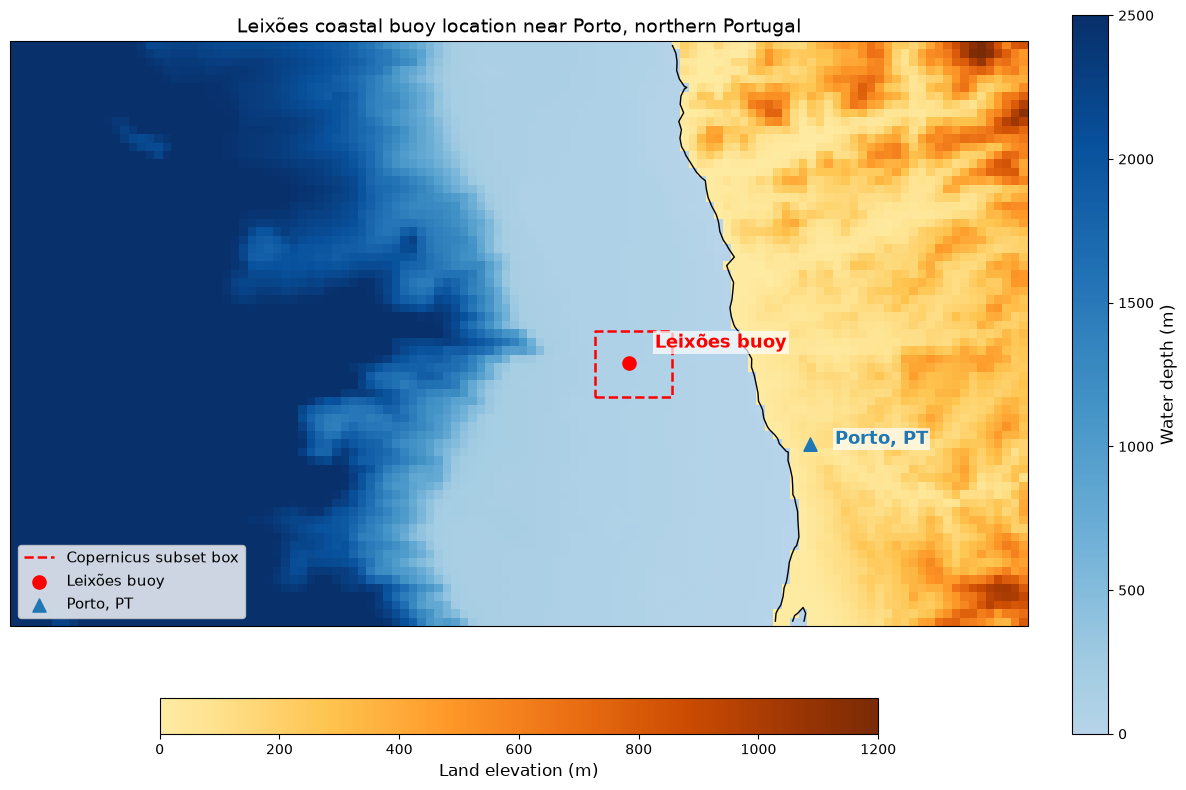

Saved figure to: ../outputs/figures/study_location_leixoes_coastal_buoy.png


In [10]:
import sys
from pathlib import Path

# Make the src/ folder importable from the notebooks/ folder
sys.path.append(str(Path("../src").resolve()))

from geo_plots import plot_near_coast_station_map

# Main Leixões buoy information
LEIXOES_PLATFORM_CODE = "Leixoes-coast-buoy"
LEIXOES_LOCATION_NAME = "leixoes_coastal_buoy"
LEIXOES_BUOY_LATITUDE = 41.317
LEIXOES_BUOY_LONGITUDE = -8.983

# Porto reference location
PORTO_LATITUDE = 41.1579
PORTO_LONGITUDE = -8.6291
PORTO_LABEL = "Porto, PT"

# Copernicus subset box for retrieving the buoy observations later
LEIXOES_SUBSET_MIN_LONGITUDE = -9.05
LEIXOES_SUBSET_MAX_LONGITUDE = -8.90
LEIXOES_SUBSET_MIN_LATITUDE = 41.25
LEIXOES_SUBSET_MAX_LATITUDE = 41.38

# Wider map area for visual context
MAP_MIN_LONGITUDE = -10.20
MAP_MAX_LONGITUDE = -8.20
MAP_MIN_LATITUDE = 40.80
MAP_MAX_LATITUDE = 41.95

# Output path for the saved figure
FIGURES_DIR = Path("../outputs/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

STUDY_LOCATION_FIGURE_PATH = (
    FIGURES_DIR / f"study_location_{LEIXOES_LOCATION_NAME}.png"
)

# Plot and save the study-location map
plot_near_coast_station_map(
    station_name="Leixões buoy",
    station_latitude=LEIXOES_BUOY_LATITUDE,
    station_longitude=LEIXOES_BUOY_LONGITUDE,
    city_name="Porto",
    city_label=PORTO_LABEL,
    city_latitude=PORTO_LATITUDE,
    city_longitude=PORTO_LONGITUDE,
    subset_min_longitude=LEIXOES_SUBSET_MIN_LONGITUDE,
    subset_max_longitude=LEIXOES_SUBSET_MAX_LONGITUDE,
    subset_min_latitude=LEIXOES_SUBSET_MIN_LATITUDE,
    subset_max_latitude=LEIXOES_SUBSET_MAX_LATITUDE,
    map_min_longitude=MAP_MIN_LONGITUDE,
    map_max_longitude=MAP_MAX_LONGITUDE,
    map_min_latitude=MAP_MIN_LATITUDE,
    map_max_latitude=MAP_MAX_LATITUDE,
    output_path=STUDY_LOCATION_FIGURE_PATH,
    figure_title="Leixões coastal buoy location near Porto, northern Portugal",
    station_color="red",
    city_color="tab:blue",
    subset_box_color="red",
    max_depth_for_colorbar_m=2500,
    max_land_elevation_for_colorbar_m=1200,
    show=True,
)

print(f"Saved figure to: {STUDY_LOCATION_FIGURE_PATH}")

Map of the study location near the Leixões coastal buoy off northern Portugal. Bathymetry and land elevation are derived from NOAA ETOPO 2022 topography/bathymetry data. The dashed box indicates the spatial subset used later to retrieve buoy observations from Copernicus Marine.

Map background data citation:

> NOAA National Centers for Environmental Information. 2022: ETOPO 2022 15 Arc-Second Global Relief Model. NOAA National Centers for Environmental Information. DOI: [10.25921/fd45-gt74](https://doi.org/10.25921/fd45-gt74). Accessed 24 Jun 2026.

## Data source and variables

The working Copernicus Marine dataset and platform used in this notebook are:

| Item | Value |
|---|---|
| Product | `INSITU_GLO_WAV_DISCRETE_MY_013_045` |
| Dataset ID | `cmems_obs-ins_glo_wav_my_na_irr` |
| Platform | Leixões coastal buoy |
| Platform code | `Leixoes-coast-buoy` |
| Platform type | Mooring |
| Institution / provider | Hydrographic Institute |
| Approximate latitude | `41.317` |
| Approximate longitude | `-8.983` |
| Native sampling observed during testing | Approximately 30 minutes |

The variables requested from Copernicus Marine are:

| Variable | Meaning | Unit | Use in this notebook and later analysis |
|---|---|---:|---|
| `time` | Observation timestamp | UTC datetime | Main time index for wave-data preparation. |
| `latitude` | Platform latitude | degrees north | Confirms station location. |
| `longitude` | Platform longitude | degrees east | Confirms station location. |
| `VHM0` | Spectral significant wave height, `Hm0` | m | Main wave-height variable for later simplified WEC power estimation and forecasting. |
| `VTPK` | Wave period at spectral peak / peak period, `Tp` | s | Main wave-period descriptor for later simplified power-matrix-style analysis. |
| `VTM02` | Spectral moments `(0,2)` wave period, `Tm02` | s | Additional period descriptor. |
| `VTZA` | Average zero-crossing wave period, `Tz` | s | Secondary period descriptor and quality/context variable. |
| `VTMX` | Maximum wave period, `Tmax` | s | Extreme/sea-state context variable. |
| `VTZM` | Period of the highest wave, `Thmax` | s | Extreme-wave context variable. |
| `VAVH` | Average height of highest one-third waves, `H1/3` | m | Secondary wave-height descriptor; useful for comparison with `VHM0`. |
| `VZMX` | Maximum zero-crossing wave height, `Hmax` | m | Extreme-wave context and quality-control support. |
| `VPED` | Wave principal direction at spectral peak | degrees | Directional feature for site characterization and optional forecasting features. |
| `VPSP` | Wave directional spreading at spectral peak | degrees | Directional spreading feature for site characterization. |
| `*_QC` | Quality-control flags for corresponding variables | code | Used to inspect and filter data quality where appropriate. |

## Retrieve raw Copernicus Marine wave observations

The following cell downloads the selected Leixões buoy wave variables from the Copernicus Marine in-situ wave dataset and saves the raw NetCDF file under `../data/raw/`.

The requested variable list includes the wave-height, period, directional, and extreme-wave descriptors confirmed during testing. `VTM10` is also requested here to check whether the spectral moments `(-1,0)` period is available for this platform.

## Copernicus Marine login

Downloading data with the Copernicus Marine Toolbox requires a Copernicus Marine account.

Registration page:

- [Copernicus Marine registration](https://data.marine.copernicus.eu/register)

After registration, log in once:

In [12]:
#import copernicusmarine
#copernicusmarine.login()

In [13]:
# Import package for Copernicus Marine data access
from pathlib import Path

import copernicusmarine

# Raw data output directory
RAW_DATA_DIR = Path("../data/raw")
RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)

# Copernicus Marine dataset information
COPERNICUS_PRODUCT_ID = "INSITU_GLO_WAV_DISCRETE_MY_013_045"
COPERNICUS_DATASET_ID = "cmems_obs-ins_glo_wav_my_na_irr"

# Requested time range
LEIXOES_START_DATETIME = "2025-02-02T00:00:00"
LEIXOES_END_DATETIME = "2026-06-24T00:00:00"

# Copernicus Marine creates a station NetCDF file inside this output folder
RAW_DOWNLOAD_FOLDER_NAME = "copernicus_leixoes_wave_20250202_20260624_raw"
RAW_DOWNLOAD_DIR = RAW_DATA_DIR / RAW_DOWNLOAD_FOLDER_NAME
RAW_NETCDF_PATH = RAW_DOWNLOAD_DIR / "Leixoes-coast-buoy.nc"

# Variables requested from the Copernicus Marine in-situ wave product
LEIXOES_WAVE_VARIABLES = [
    "VHM0",    # spectral significant wave height (Hm0)
    "VTPK",    # wave period at spectral peak / peak period (Tp)
    "VTM10",   # spectral moments (-1,0) wave period (Tm-10)
    "VTM02",   # spectral moments (0,2) wave period (Tm02)
    "VTZA",    # average zero-crossing wave period (Tz)
    "VTMX",    # maximum wave period (Tmax)
    "VTZM",    # period of the highest wave (Thmax)
    "VAVH",    # average height of highest one-third waves (H1/3)
    "VZMX",    # maximum zero-crossing wave height (Hmax)
    "VPED",    # wave principal direction at spectral peak
    "VPSP",    # wave directional spreading at spectral peak
]

# Download only if the station NetCDF file is not already present
if RAW_NETCDF_PATH.exists():
    print(f"Raw file already exists, skipping download: {RAW_NETCDF_PATH}")
    download_response = None
else:
    download_response = copernicusmarine.subset(
        dataset_id=COPERNICUS_DATASET_ID,
        variables=LEIXOES_WAVE_VARIABLES,
        minimum_longitude=LEIXOES_SUBSET_MIN_LONGITUDE,
        maximum_longitude=LEIXOES_SUBSET_MAX_LONGITUDE,
        minimum_latitude=LEIXOES_SUBSET_MIN_LATITUDE,
        maximum_latitude=LEIXOES_SUBSET_MAX_LATITUDE,
        start_datetime=LEIXOES_START_DATETIME,
        end_datetime=LEIXOES_END_DATETIME,
        output_directory=str(RAW_DATA_DIR),
        output_filename=RAW_DOWNLOAD_FOLDER_NAME,
    )

    print(f"Downloaded raw file to: {RAW_NETCDF_PATH}")

download_response

Raw file already exists, skipping download: ../data/raw/copernicus_leixoes_wave_20250202_20260624_raw/Leixoes-coast-buoy.nc
